In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("All libraries imported successfully!")


All libraries imported successfully!


In [10]:
data = pd.read_csv("C:/Users/sirip/Downloads/framingham.csv")

In [13]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [14]:
data.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [15]:
data.sample(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
2309,0,46,2.0,0,0.0,0.0,0,0,0,275.0,116.0,88.5,28.04,70.0,70.0,0
2979,0,45,2.0,0,0.0,0.0,0,1,0,258.0,148.5,88.0,23.46,85.0,90.0,0
4016,1,62,2.0,1,20.0,0.0,0,0,0,264.0,129.0,85.0,26.15,73.0,63.0,0
3074,0,63,2.0,0,0.0,0.0,0,1,0,184.0,196.0,101.0,28.27,86.0,82.0,1
3535,0,60,2.0,1,20.0,0.0,0,0,0,260.0,139.0,81.0,24.68,74.0,70.0,0


In [16]:
data.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [17]:
data.shape

(4238, 16)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [26]:
data.describe()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [27]:
data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_percentage.sort_values(
    ascending=False
)

glucose            9.155262
education          2.477584
BPMeds             1.250590
totChol            1.179802
cigsPerDay         0.684285
BMI                0.448325
heartRate          0.023596
male               0.000000
prevalentHyp       0.000000
prevalentStroke    0.000000
age                0.000000
currentSmoker      0.000000
diaBP              0.000000
sysBP              0.000000
diabetes           0.000000
TenYearCHD         0.000000
dtype: float64

In [21]:
data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_percentage.sort_values(
    ascending=False
)

glucose            9.155262
education          2.477584
BPMeds             1.250590
totChol            1.179802
cigsPerDay         0.684285
BMI                0.448325
heartRate          0.023596
male               0.000000
prevalentHyp       0.000000
prevalentStroke    0.000000
age                0.000000
currentSmoker      0.000000
diaBP              0.000000
sysBP              0.000000
diabetes           0.000000
TenYearCHD         0.000000
dtype: float64

In [28]:
duplicate_values = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_values)

Number of duplicate rows: 0


In [29]:
data["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [30]:
target_percentage = data["TenYearCHD"].value_counts(normalize=True) * 100

print(target_percentage)

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


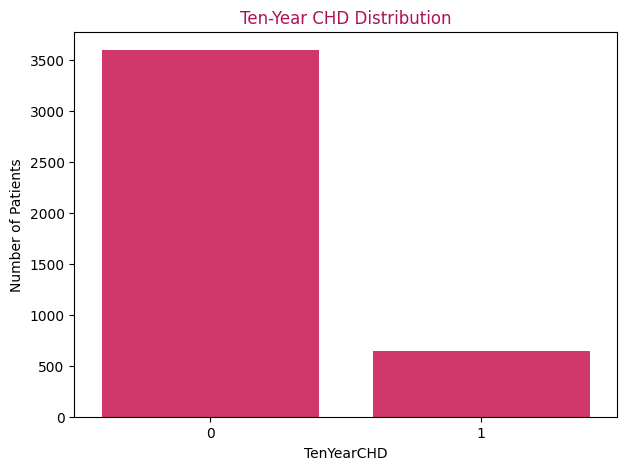

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="TenYearCHD",
    color="#E91E63"
)

plt.title("Ten-Year CHD Distribution", color="#AD1457")
plt.xlabel("TenYearCHD")
plt.ylabel("Number of Patients")

plt.show()

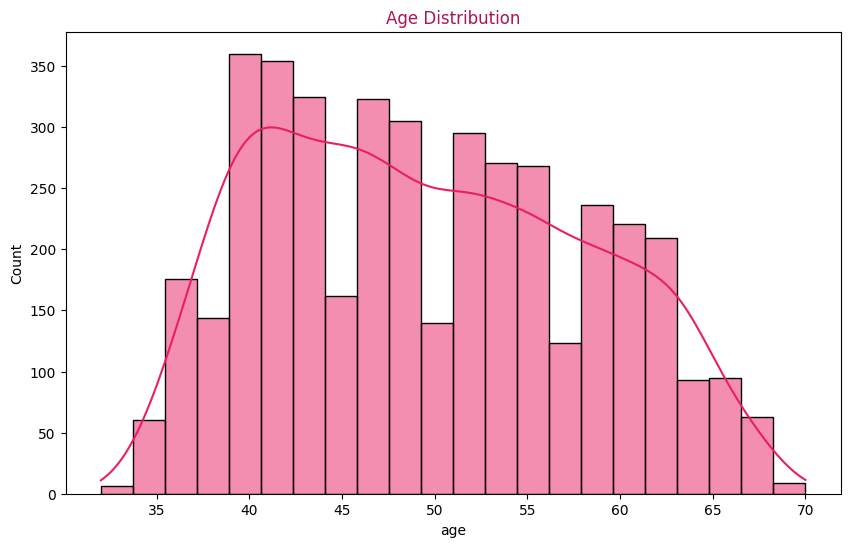

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="age",
    kde=True,
    color="#E91E63"
)

plt.title("Age Distribution", color="#AD1457")

plt.show()

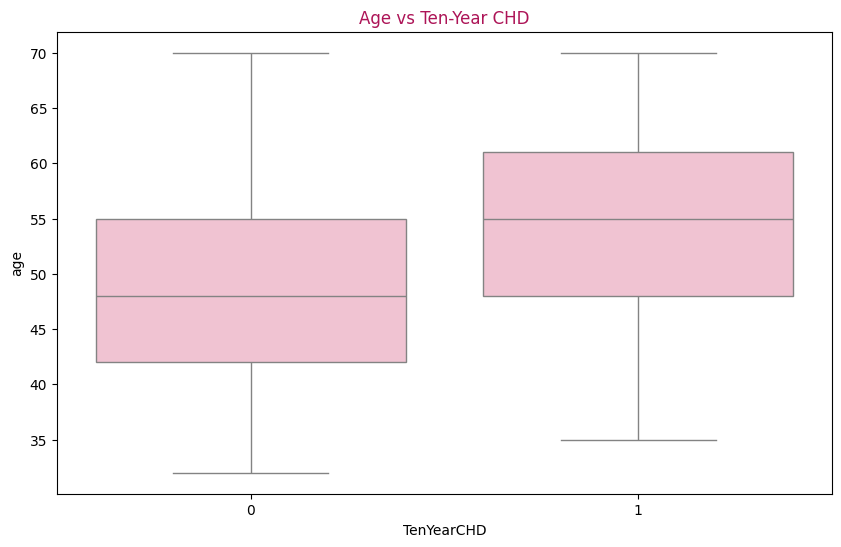

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="TenYearCHD",
    y="age",
    color="#F8BBD0"
)

plt.title("Age vs Ten-Year CHD", color="#AD1457")

plt.show()

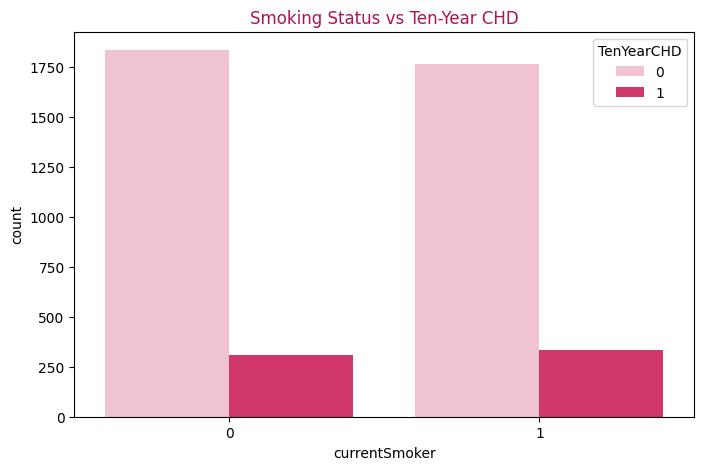

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="currentSmoker",
    hue="TenYearCHD",
    palette=["#F8BBD0", "#E91E63"]
)

plt.title("Smoking Status vs Ten-Year CHD", color="#AD1457")

plt.show()

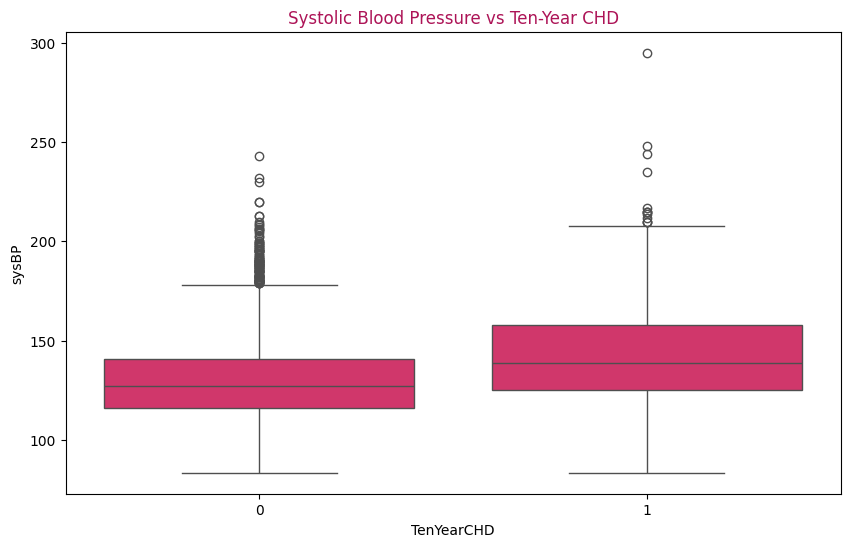

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="TenYearCHD",
    y="sysBP",
    color="#E91E63"
)

plt.title(
    "Systolic Blood Pressure vs Ten-Year CHD",
    color="#AD1457"
)

plt.show()

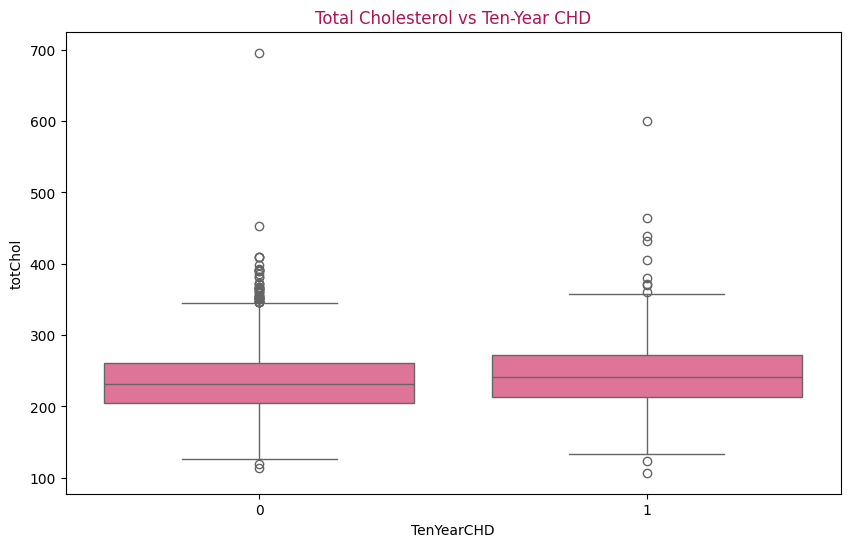

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="TenYearCHD",
    y="totChol",
    color="#F06292"
)

plt.title(
    "Total Cholesterol vs Ten-Year CHD",
    color="#AD1457"
)

plt.show()

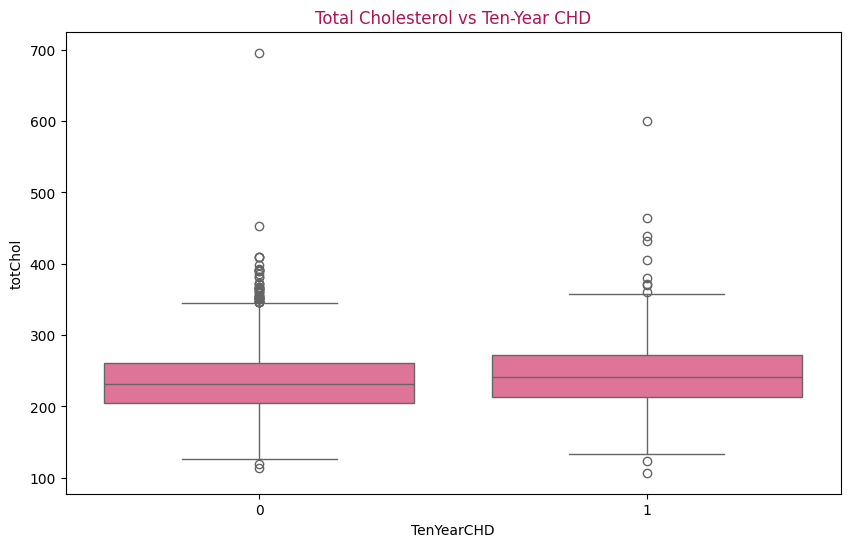

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="TenYearCHD",
    y="totChol",
    color="#F06292"
)

plt.title(
    "Total Cholesterol vs Ten-Year CHD",
    color="#AD1457"
)

plt.show()


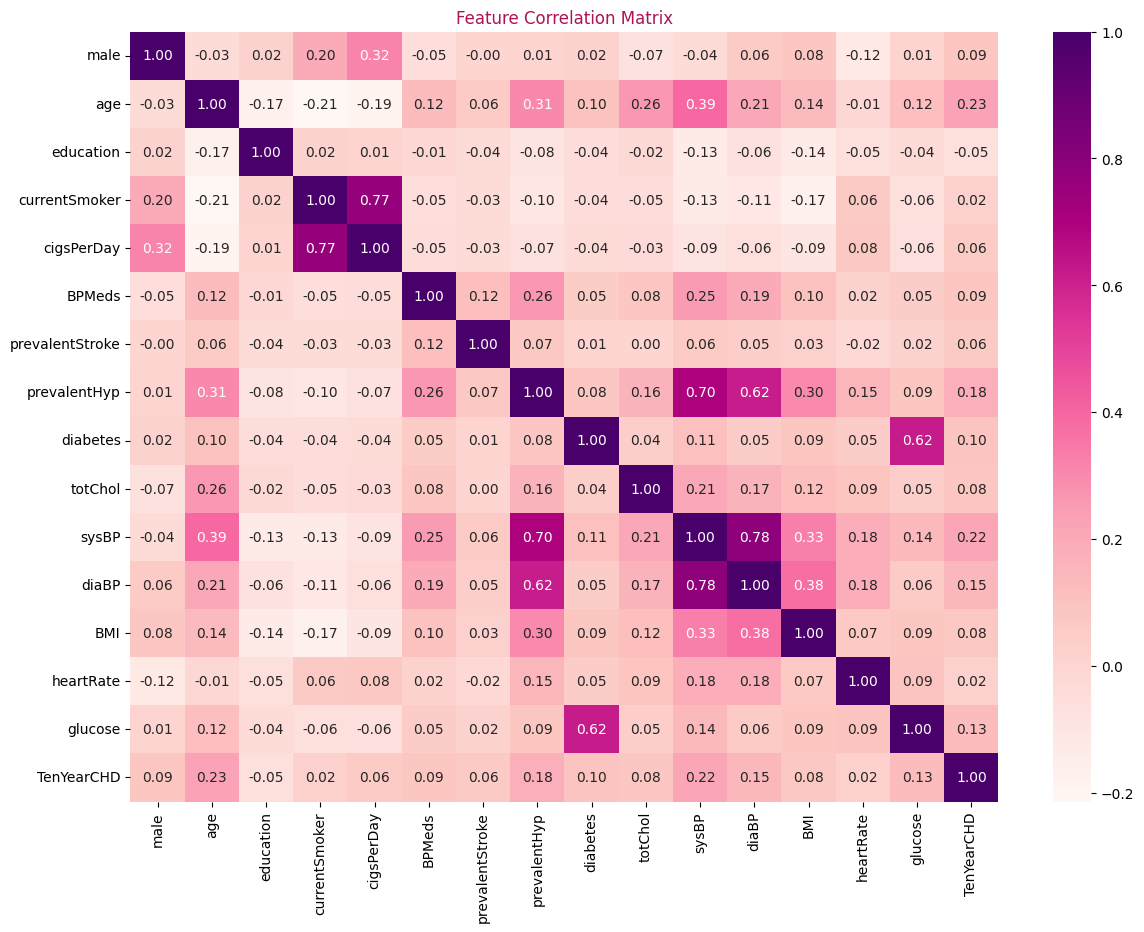

In [39]:
plt.figure(figsize=(14, 10))

correlation = data.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="RdPu"
)

plt.title(
    "Feature Correlation Matrix",
    color="#AD1457"
)

plt.show()

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)

In [50]:
X = data.drop("TenYearCHD", axis=1)
y = data["TenYearCHD"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4238, 15)
y shape: (4238,)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3390
Testing samples: 848


In [52]:
rf_model = models["Random Forest"]

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [53]:
rf_classifier = rf_model.named_steps["model"]

feature_importance = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

            Feature  Importance
1               age    0.211870
10            sysBP    0.151527
11            diaBP    0.102890
12              BMI    0.093494
9           totChol    0.091808
14          glucose    0.089390
13        heartRate    0.071649
4        cigsPerDay    0.056171
7      prevalentHyp    0.042080
2         education    0.028267
0              male    0.027651
3     currentSmoker    0.011525
8          diabetes    0.010906
5            BPMeds    0.008101
6   prevalentStroke    0.002672


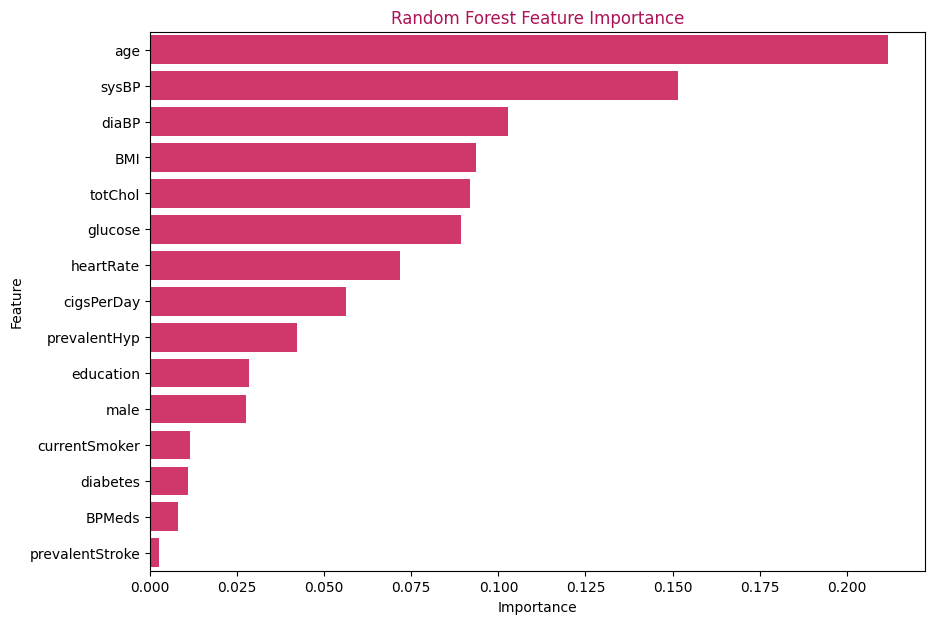

In [54]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    color="#E91E63"
)

plt.title(
    "Random Forest Feature Importance",
    color="#AD1457"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [56]:
models
X_train
X_test
y_train
y_test

1305    0
4132    0
2175    1
3540    0
2966    0
       ..
3620    0
3923    0
3127    0
3071    0
821     0
Name: TenYearCHD, Length: 848, dtype: int64

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

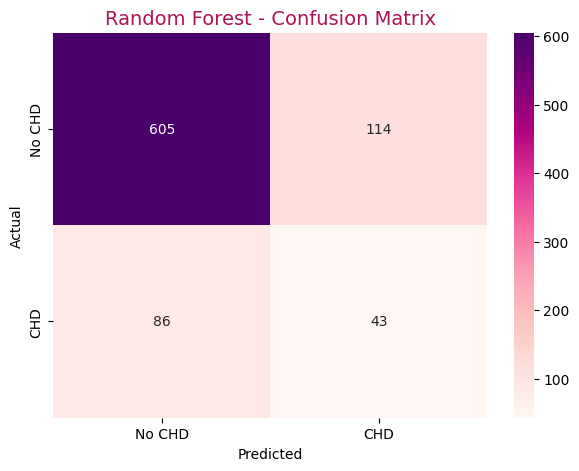

In [62]:
from sklearn.metrics import confusion_matrix

y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdPu",
    xticklabels=["No CHD", "CHD"],
    yticklabels=["No CHD", "CHD"]
)

plt.title(
    "Random Forest - Confusion Matrix",
    color="#AD1457",
    fontsize=14
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [63]:



rf_classifier = rf_model.named_steps["model"]

feature_importance = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

            Feature  Importance
1               age    0.211870
10            sysBP    0.151527
11            diaBP    0.102890
12              BMI    0.093494
9           totChol    0.091808
14          glucose    0.089390
13        heartRate    0.071649
4        cigsPerDay    0.056171
7      prevalentHyp    0.042080
2         education    0.028267
0              male    0.027651
3     currentSmoker    0.011525
8          diabetes    0.010906
5            BPMeds    0.008101
6   prevalentStroke    0.002672


In [64]:
rf_classifier = rf_model.named_steps["model"]

feature_importance = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

            Feature  Importance
1               age    0.211870
10            sysBP    0.151527
11            diaBP    0.102890
12              BMI    0.093494
9           totChol    0.091808
14          glucose    0.089390
13        heartRate    0.071649
4        cigsPerDay    0.056171
7      prevalentHyp    0.042080
2         education    0.028267
0              male    0.027651
3     currentSmoker    0.011525
8          diabetes    0.010906
5            BPMeds    0.008101
6   prevalentStroke    0.002672


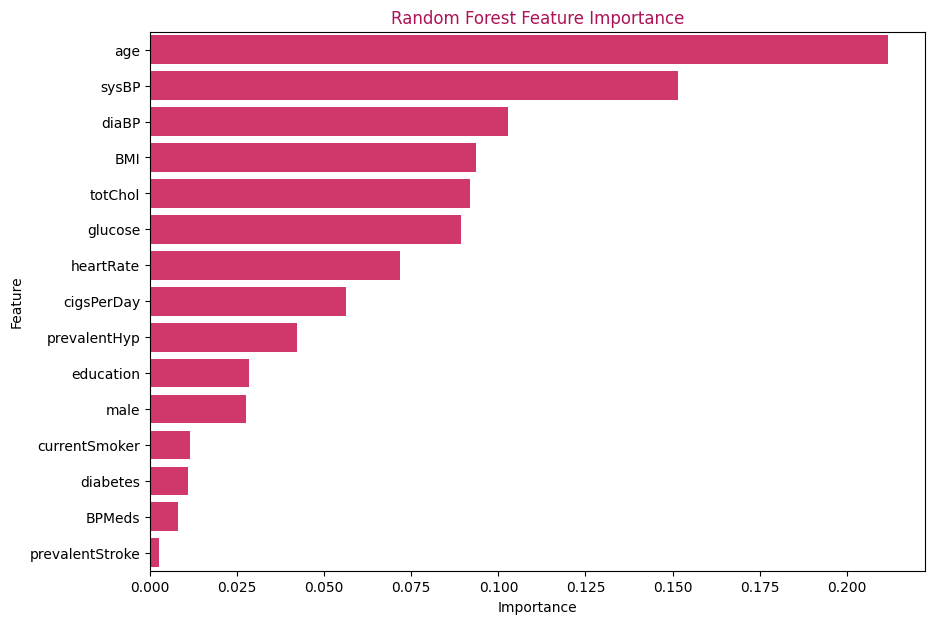

In [68]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    color="#E91E63"
)

plt.title(
    "Random Forest Feature Importance",
    color="#AD1457"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

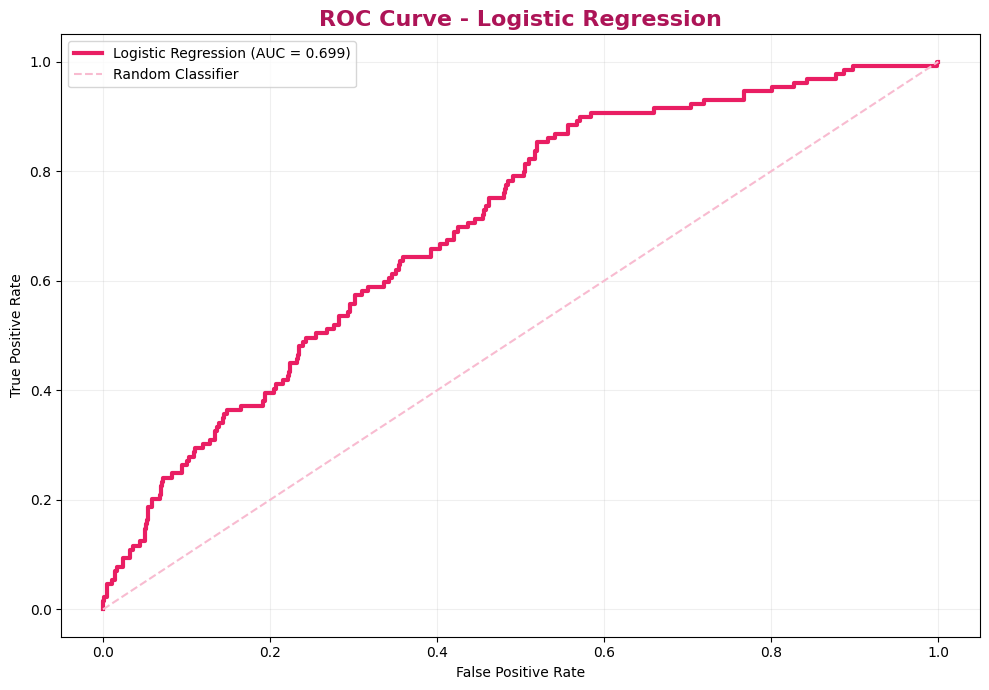

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Select Logistic Regression
model = models["Logistic Regression"]

# Train the model
model.fit(X_train, y_train)

# Get probability predictions
y_probability = model.predict_proba(X_test)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_probability)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    color="#E91E63",
    linewidth=3,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="#F8BBD0",
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Logistic Regression",
    color="#AD1457",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()